In [29]:
import torch
import torch.nn.functional as F
from torchvision import transforms
from einops import rearrange
from PIL import Image
import numpy as np
import skdim

from app import train_mood_space, interpolate_two_images
from dino_clip_featextract import extract_dino_image_embeds, extract_dinov3_image_embeds, extract_clip_image_embeds
from my_ipadapter_model import load_ipadapter, image_grid, generate

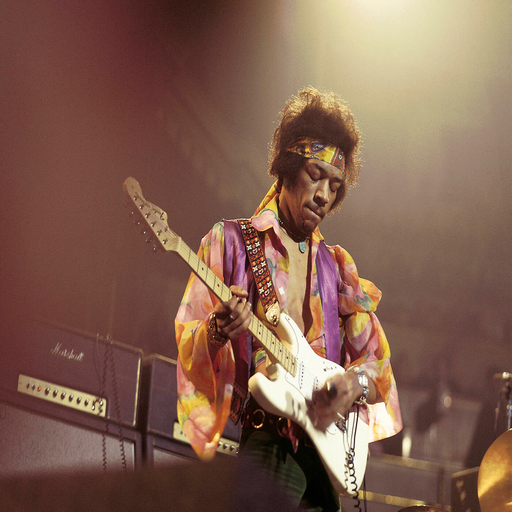

In [3]:
path = "./images/jimi_action.jpg"
image1 = Image.open(path).resize((512, 512), resample=Image.Resampling.LANCZOS).convert("RGB")
image1

In [8]:
ip_model = load_ipadapter()

Loading pipeline components...: 100%|██████████| 5/5 [00:00<00:00,  8.53it/s]


In [33]:
clip_img_transform = transforms.Compose([
    transforms.Resize((896, 896)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

clip_input_images = torch.stack([clip_img_transform(image1)])
clip_image_embeds = extract_clip_image_embeds(clip_input_images)
print(clip_image_embeds.shape)

Loading pipeline components...: 100%|██████████| 5/5 [00:00<00:00,  9.61it/s]


torch.Size([1, 4097, 1280])


In [34]:
hw = int((clip_image_embeds.shape[1] - 1) ** 0.5)
interpolated_patch_tokens = rearrange(clip_image_embeds[:, 1:, :], 'b (h w) c -> b c h w', h=hw, w=hw)

interpolated_patch_tokens = F.avg_pool2d(interpolated_patch_tokens, kernel_size=4, stride=4)
interpolated_patch_tokens = rearrange(interpolated_patch_tokens, 'b c h w -> b (h w) c')
clip_image_embeds = torch.cat([clip_image_embeds[:, :1, :], interpolated_patch_tokens], dim=1)

print(clip_image_embeds.shape)

torch.Size([1, 257, 1280])


  0%|          | 0/50 [00:00<?, ?it/s]

100%|██████████| 50/50 [00:01<00:00, 46.54it/s]


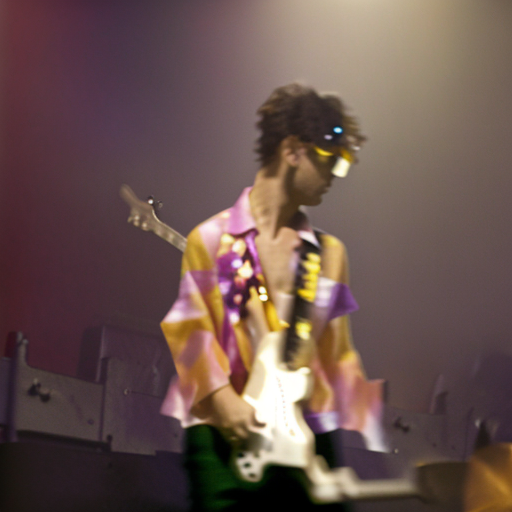

In [35]:
gen_images = generate(ip_model, clip_image_embeds, num_samples=1, seed=42)
gen_images[0]